<a href="https://colab.research.google.com/github/AnkaRezaa/machine_learning_254107023002/blob/main/JS04/studi_kasus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Studi Kasus Akademik: Perbandingan K-Means dan DBSCAN untuk Clustering Risiko Obesitas**

Studi kasus yang saya kerjakan adalah sebuah kasus untuk perbandingan Kmeans dan DBscan untuk resiko Obesitas yang dikemukakan oleh  Geovani, Umari, dan Ramadini (2024)

### Jurnal yang saya peroleh adalah sebagai berikut : **Geovani, Umari, dan Ramadini (2024), “Cluster Analysis of Obesity Risk Levels Using K-Means And DBScan Methods”**


Dataset berisi 2.111 observasi dan 17 atribut total—16 fitur plus label tingkat obesitas—dari
individu di Meksiko, Peru, dan Kolombia. UCI menyatakan tidak ada missing values; 23% data berasal
dari pengguna dan 77% merupakan data sintetis yang dibangkitkan menggunakan Weka/SMOTE.

Eksperimen utama membandingkan K-Means
k=2 dengan DBSCAN eps=1.4 , 2min_samples=5 .
dalam laporan ini keduanya menghasilkan partisi yang persis sama: cluster perempuan 935
observasi dan cluster laki-laki 985 observasi.



### SITASI : **Geovani, D., Umari, Z., & Ramadini, S. (2024). Cluster Analysis of Obesity Risk Levels Using K-Means And DBScan Methods. Computer Engineering and Applications Journal, 13(3), 10-24. DOI: 10.18495/comengapp.v13i3.481.**

link : https://comengapp.unsri.ac.id/index.php/comengapp/article/view/481

In [1]:
!unzip "/content/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"

Archive:  /content/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip
  inflating: ObesityDataSet_raw_and_data_sinthetic.csv  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Studi Kasus Akademik: Perbandingan K-Means dan DBSCAN untuk Clustering Risiko Obesitas**

### **K-MEANS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
# Berdasarkan Gaya Hidup
features = ['Age', 'FAF']   # Bisa diganti ['Weight', 'Height'] jika ingin fisik
X = df[features].copy()

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

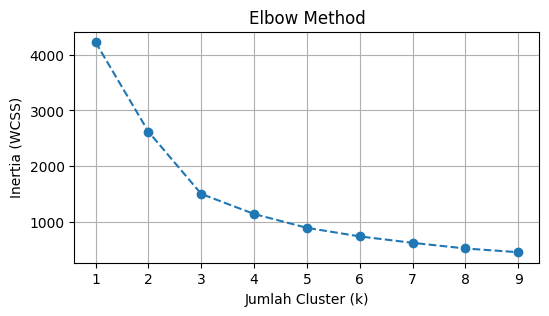

In [9]:
# cek elbow

wcss = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

In [10]:
k = 3  # Tentukan nilai k (misal: Rendah, Sedang, Tinggi)
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Fitting K-Means
sil_score = silhouette_score(X_scaled, df['Cluster_KMeans'])
print(f"Silhouette Score untuk k={k}: {sil_score:.4f}")

In [ ]:
# Evaluasi Kualitas Klaster dengan Silhouette Score
sil_score = silhouette_score(X_scaled, df['Cluster_KMeans'])
print(f"Silhouette Score untuk k={k}: {sil_score:.4f}")

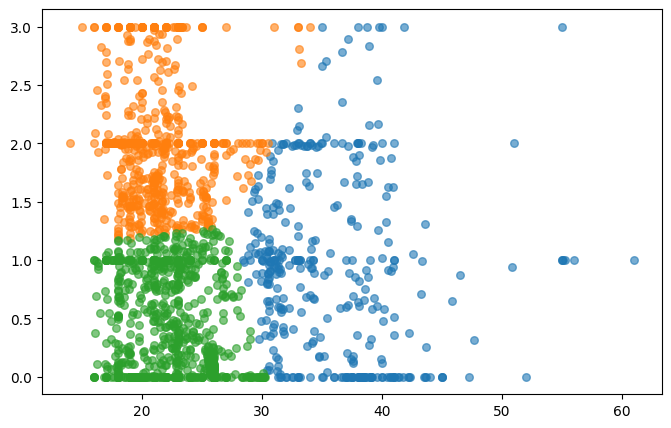

In [11]:
# Visualisasi Hasil Clustering & Centroid
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_data = df[df['Cluster_KMeans'] == i]
    plt.scatter(
        cluster_data[features[0]],
        cluster_data[features[1]],
        label=f'Cluster {i}',
        alpha=0.6,
        s=30
    )

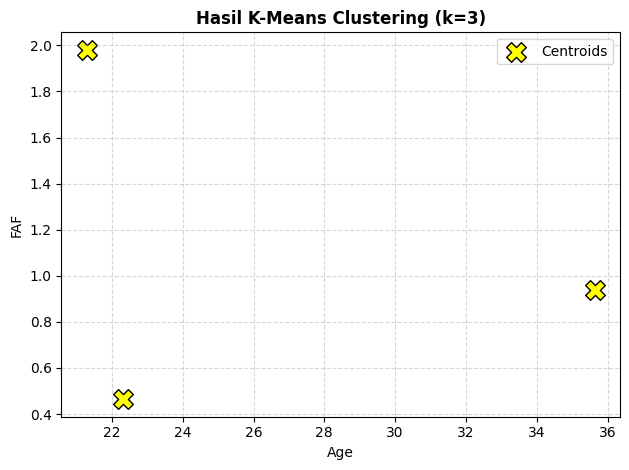

In [17]:
# Kembalikan koordinat centroid ke skala asli untuk diplot

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=200,
    c='yellow',
    edgecolors='black',
    marker='X',
    label='Centroids'
)

plt.title(f'Hasil K-Means Clustering (k={k})', fontsize=12, fontweight='bold')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# Profiling Rata-rata per Klaster
print("\nKarakteristik Tiap Klaster:")
print(df.groupby('Cluster_KMeans')[features].mean())


Karakteristik Tiap Klaster:
                      Age       FAF
Cluster_KMeans                     
0               35.635587  0.936821
1               21.290592  1.980876
2               22.318063  0.464255


### **DB-SCANS**

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from sklearn.datasets import make_moons
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score,
    confusion_matrix
)

In [25]:
#MENGAMBUL FITUR YANG SAMA DENGAN KMEANS

features = ['Age', 'FAF']
X = df[features].copy()

In [26]:
y_true = df['NObeyesdad'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
dbscan = DBSCAN(eps=0.35, min_samples=5, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = labels_dbscan

In [28]:
unique_labels = set(labels_dbscan)
n_clusters = len(unique_labels - {-1})
n_noise = list(labels_dbscan).count(-1)

print(f"Jumlah klaster terbentuk : {n_clusters}")
print(f"Jumlah data noise (-1)   : {n_noise} ({n_noise / len(df) * 100:.2f}%)")

Jumlah klaster terbentuk : 3
Jumlah data noise (-1)   : 12 (0.57%)


In [29]:
print("\n" + "="*40)
print("       HASIL EVALUASI METRIK DBSCAN       ")
print("="*40)
print(f"Homogeneity Score       : {homogeneity_score(y_true, labels_dbscan):.4f}")
print(f"Completeness Score      : {completeness_score(y_true, labels_dbscan):.4f}")
print(f"V-Measure Score         : {v_measure_score(y_true, labels_dbscan):.4f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(y_true, labels_dbscan):.4f}")
print(f"Adjusted Mutual Info(AMI): {adjusted_mutual_info_score(y_true, labels_dbscan):.4f}")


       HASIL EVALUASI METRIK DBSCAN       
Homogeneity Score       : 0.0068
Completeness Score      : 0.1337
V-Measure Score         : 0.0129
Adjusted Rand Index (ARI): 0.0000
Adjusted Mutual Info(AMI): 0.0081


In [30]:
core_mask = labels_dbscan != -1
if len(set(labels_dbscan[core_mask])) >= 2:
    sil_val = silhouette_score(X_scaled[core_mask], labels_dbscan[core_mask])
    print(f"Silhouette Score (Core) : {sil_val:.4f}")
else:
    print("Silhouette Score        : Tidak dapat dihitung (klaster inti < 2)")
print("="*40)

Silhouette Score (Core) : 0.4356


In [31]:
plt.figure(figsize=(9, 6))

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

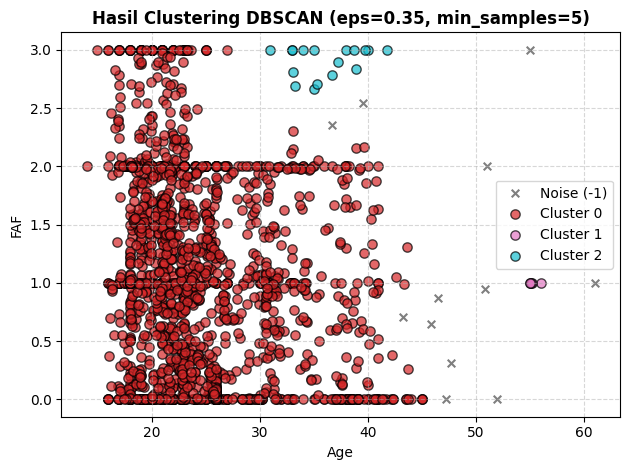

In [32]:
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for k, col in zip(sorted(unique_labels), colors):
    member_mask = (labels_dbscan == k)
    xy = X.to_numpy()[member_mask]

    if k == -1:
        # Titik outlier/noise
        plt.scatter(
            xy[:, 0], xy[:, 1],
            c='black',
            marker='x',
            s=30,
            alpha=0.5,
            label='Noise (-1)'
        )
    else:
        # Titik anggota klaster valid
        plt.scatter(
            xy[:, 0], xy[:, 1],
            c=[col],
            edgecolors='k',
            s=45,
            alpha=0.7,
            label=f'Cluster {k}'
        )

plt.title(f'Hasil Clustering DBSCAN (eps={dbscan.eps}, min_samples={dbscan.min_samples})', fontsize=12, fontweight='bold')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

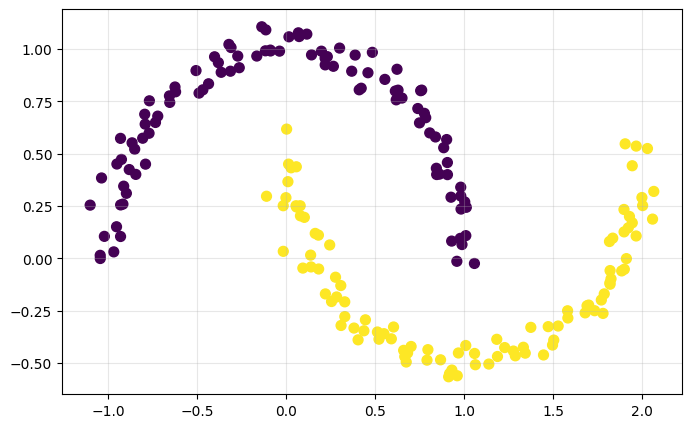

In [35]:
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.grid(True, alpha=0.3)
plt.show()

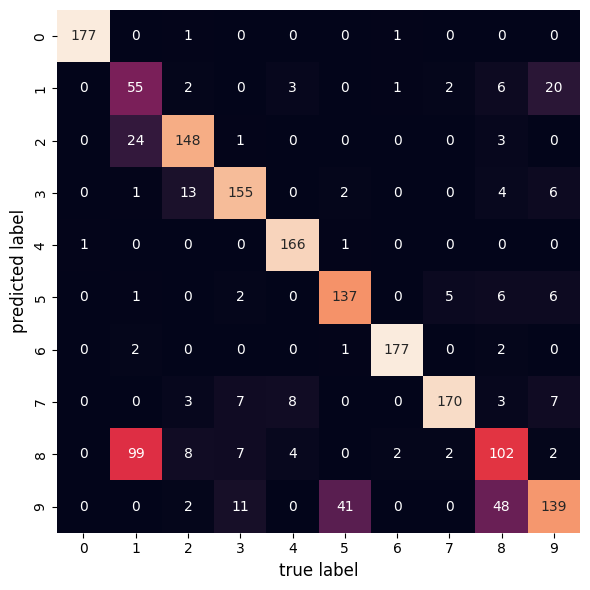

In [38]:
digits = load_digits()
X, y_true = digits.data, digits.target

# 2. Klastering dengan KMeans (10 klaster untuk digit 0-9)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# 3. Petakan nomor klaster KMeans ke label sebenarnya (karena urutan nomor klaster acak)
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    # Tentukan label mayoritas untuk klaster tersebut
    labels[mask] = mode(y_true[mask], keepdims=True)[0]

# 4. Hitung Confusion Matrix
# Perhatikan urutan argumen: (predicted_label, true_label) agar sumbu Y adalah predicted
mat = confusion_matrix(labels, y_true)

# 5. Visualisasi Heatmap Confusion Matrix persis seperti gambar
plt.figure(figsize=(7, 6))
sns.heatmap(
    mat,
    annot=True,
    fmt='d',
    cbar=False,
    square=True,
    cmap='rocket'
)

plt.xlabel('true label', fontsize=12)
plt.ylabel('predicted label', fontsize=12)
plt.tight_layout()
plt.show()